In [2]:
import pandas as pd


In [3]:
df=pd.read_csv("raw_data.csv")
df
df.dropna()
df.dropna(axis=1)

cleaned_data=df.copy()
age_mean=cleaned_data["age"].mean()
cleaned_data["age"]=cleaned_data["age"].fillna(age_mean)
cleaned_data

cleaned_data["income"]=cleaned_data["income"].ffill()
cleaned_data


,id,name,age,country,gender,income
0,1,John Doe,29.00,USA,Male,55000.0
1,1,John Doe,29.00,USA,Male,55000.0
2,2,Jane Smith,32.75,Canada,Female,62000.0
3,3,Alex,32.75,USA,Unknown,47000.0
4,4,Maria Garcia,34.00,Spain,Female,47000.0
5,5,Li Wei,27.00,China,Male,51000.0
6,6,NaN,45.00,India,Female,73000.0
7,7,Ahmed Khan,38.00,NaN,Male,68000.0
8,8,Rachel Lee,29.00,USA,Female,62000.0
9,9,Carlos Ruiz,32.75,Mexico,Male,45000.0


In [4]:

cleaned_data=cleaned_data.drop_duplicates()
cleaned_data
cleaned_data.duplicated()
 

0     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
dtype: bool

In [18]:
df2=df.copy()
df2["tax"]=df2["income"].apply(lambda x:"20%" if x>=5000 else "10%")
df2

gender_map={"Male":"M","Female":"F","unknown":"U"}
df2["gender"]=df2["gender"].map(gender_map)
df2
#rename column

df2.sort_values("income" )
df2

,id,name,age,country,gender,income,tax
0,1,John Doe,29.0,USA,M,55000.0,20%
1,1,John Doe,29.0,USA,M,55000.0,20%
2,2,Jane Smith,NaN,Canada,F,62000.0,20%
3,3,Alex,NaN,USA,NaN,47000.0,20%
4,4,Maria Garcia,34.0,Spain,F,NaN,10%
5,5,Li Wei,27.0,China,M,51000.0,20%
6,6,NaN,45.0,India,F,73000.0,20%
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%
8,8,Rachel Lee,29.0,USA,F,62000.0,20%
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,20%


In [29]:
df3=df.copy()
new_col_order=[col for col in df3.columns if col !="id"]+["id"]
print(new_col_order)
df3=df3[new_col_order]
df3

df3=df.drop_duplicates()
df3=df.fillna(0)
df3=df3.sort_values("income")
df3.reset_index(drop=True)
df3.to_csv("clean_data.csv")

df3


['name', 'age', 'country', 'gender', 'income', 'id']


,name,age,country,gender,income,id
0,John Doe,29.0,USA,Male,55000.0,1
1,John Doe,29.0,USA,Male,55000.0,1
2,Jane Smith,NaN,Canada,Female,62000.0,2
3,Alex,NaN,USA,Unknown,47000.0,3
4,Maria Garcia,34.0,Spain,Female,NaN,4
5,Li Wei,27.0,China,Male,51000.0,5
6,NaN,45.0,India,Female,73000.0,6
7,Ahmed Khan,38.0,NaN,Male,68000.0,7
8,Rachel Lee,29.0,USA,Female,62000.0,8
9,Carlos Ruiz,NaN,Mexico,Male,45000.0,9


In [32]:
print(df3.groupby("country")["income"].mean())
print(df3.groupby("country")["income"].sum())
print(df3.groupby("age")["income"].max())

country
Canada    62000.0
China     51000.0
India     73000.0
Mexico    45000.0
Spain         NaN
USA       55400.0
Name: income, dtype: float64
country
Canada     62000.0
China      51000.0
India      73000.0
Mexico     45000.0
Spain          0.0
USA       277000.0
Name: income, dtype: float64
age
27.0    51000.0
29.0    62000.0
31.0    58000.0
34.0        NaN
38.0    68000.0
45.0    73000.0
Name: income, dtype: float64


In [43]:
df=pd.DataFrame({
    "country":["usa","usa","india","india"],
    "year":[2020,2021,2020,2021],
    "sales":[100,120,90,110],
    "profit":[20,25,18,22]
})
melted_df=df.melt(
    id_vars=["country","year"],
    value_vars=["sales","profit"],
    var_name="metrics",
    value_name="value"
    
)
print(melted_df)
original=melted_df.pivot(
    index=["country","year"],
    columns="metrics",
    values="value"
)
print(original)


  country  year metrics  value
0     usa  2020   sales    100
1     usa  2021   sales    120
2   india  2020   sales     90
3   india  2021   sales    110
4     usa  2020  profit     20
5     usa  2021  profit     25
6   india  2020  profit     18
7   india  2021  profit     22
metrics       profit  sales
country year               
india   2020      18     90
        2021      22    110
usa     2020      20    100
        2021      25    120


In [38]:
df

,country,year,sales,profit
0,usa,2020,100,20
1,usa,2021,120,25
2,india,2020,90,18
3,india,2021,110,22


<Axes: >

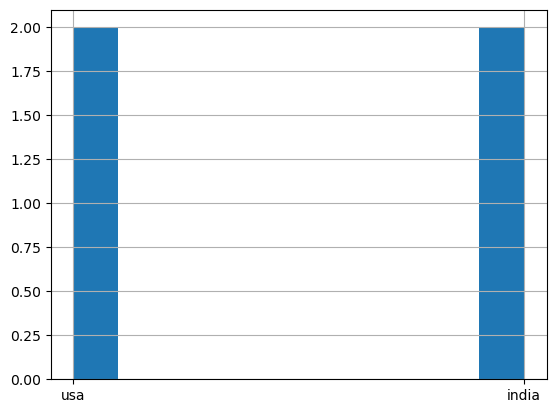

In [46]:
df["country"].hist()
